In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import os.path
import logging
import argparse
import datetime
import mrcfile
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from PIL import Image
import sys
import time
import pickle
sys.path.append("/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/models")
sys.path.append("/home/bcl/wanghongyu/wanghongyu_humx/dynamic/tools")
from visualization.vis import plot_images
from models.wasserstein2_loss import Wasserstein2Loss
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [24]:
down_sample = True
scale_h = 4
scale_w = 4

with h5py.File('/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/data/sampleA/sample_A+_20160601.hdf', 'r') as f:
    for name in f:
        print(":", name)
    data_type = f["__DATA_TYPES__"]
    raw_data = f['volumes/raw']
    dataset = np.array(raw_data)

if down_sample:
    x = torch.from_numpy(dataset).unsqueeze(1).float()  # shape (N,1,H,W)
    pool = torch.nn.AvgPool2d(kernel_size=(scale_h, scale_w))
    data = pool(x).squeeze(1).numpy()
else:
    data = dataset
data_t = torch.from_numpy(data).to(torch.float)
data_t  = data_t/255
data_t = data_t.to('cuda')
data_t.shape, data.shape

: __DATA_TYPES__
: volumes


(torch.Size([125, 312, 312]), (125, 312, 312))

In [15]:
from models.data import SlicePreprocessor
from models.lddmm import LDDMM
from models.train import train_global_alignment

slicepreprocessor = SlicePreprocessor(
    target_size=None,
    scale_factor=None,
    sum_target=data_t.sum(dim=(1,2)).mean().item(),
    mean=None,
    std=None,
    clamp_min=None,
    clamp_max=None,
    interp_mode="bilinear",
    align_corners=False,
)

In [ ]:
scale4reg = 10
train_global_alignment(slices = data_t.unsqueeze(1), 
output_dir="/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/outputs",
r = 3,
weights = torch.tensor([0.05,0.15,0.3,0.3,0.15,0.05], device='cuda'),
loss_func = "W2",
epochs = 200,
lr = 1e-2,
reg_grad = 1e-3*scale4reg,
reg_time = 1e-3*scale4reg,
reg_l2 = 1e-3*scale4reg,
early_stop_window = 10,
early_stop_delta = 1e-4,
save_interval = 50,
device = torch.device("cuda"),
w2_paras = {'eps': 1e-8, 'maxiter': 100},
preprocess = None,
lddmm_kwargs = {
        'time_steps': 10,
        'smooth_sigma': 1.0,
        'interp_mode': "bicubic",
        'padding_mode': "border",
        'align_corners': True,
        'mass_preserve': False},
)

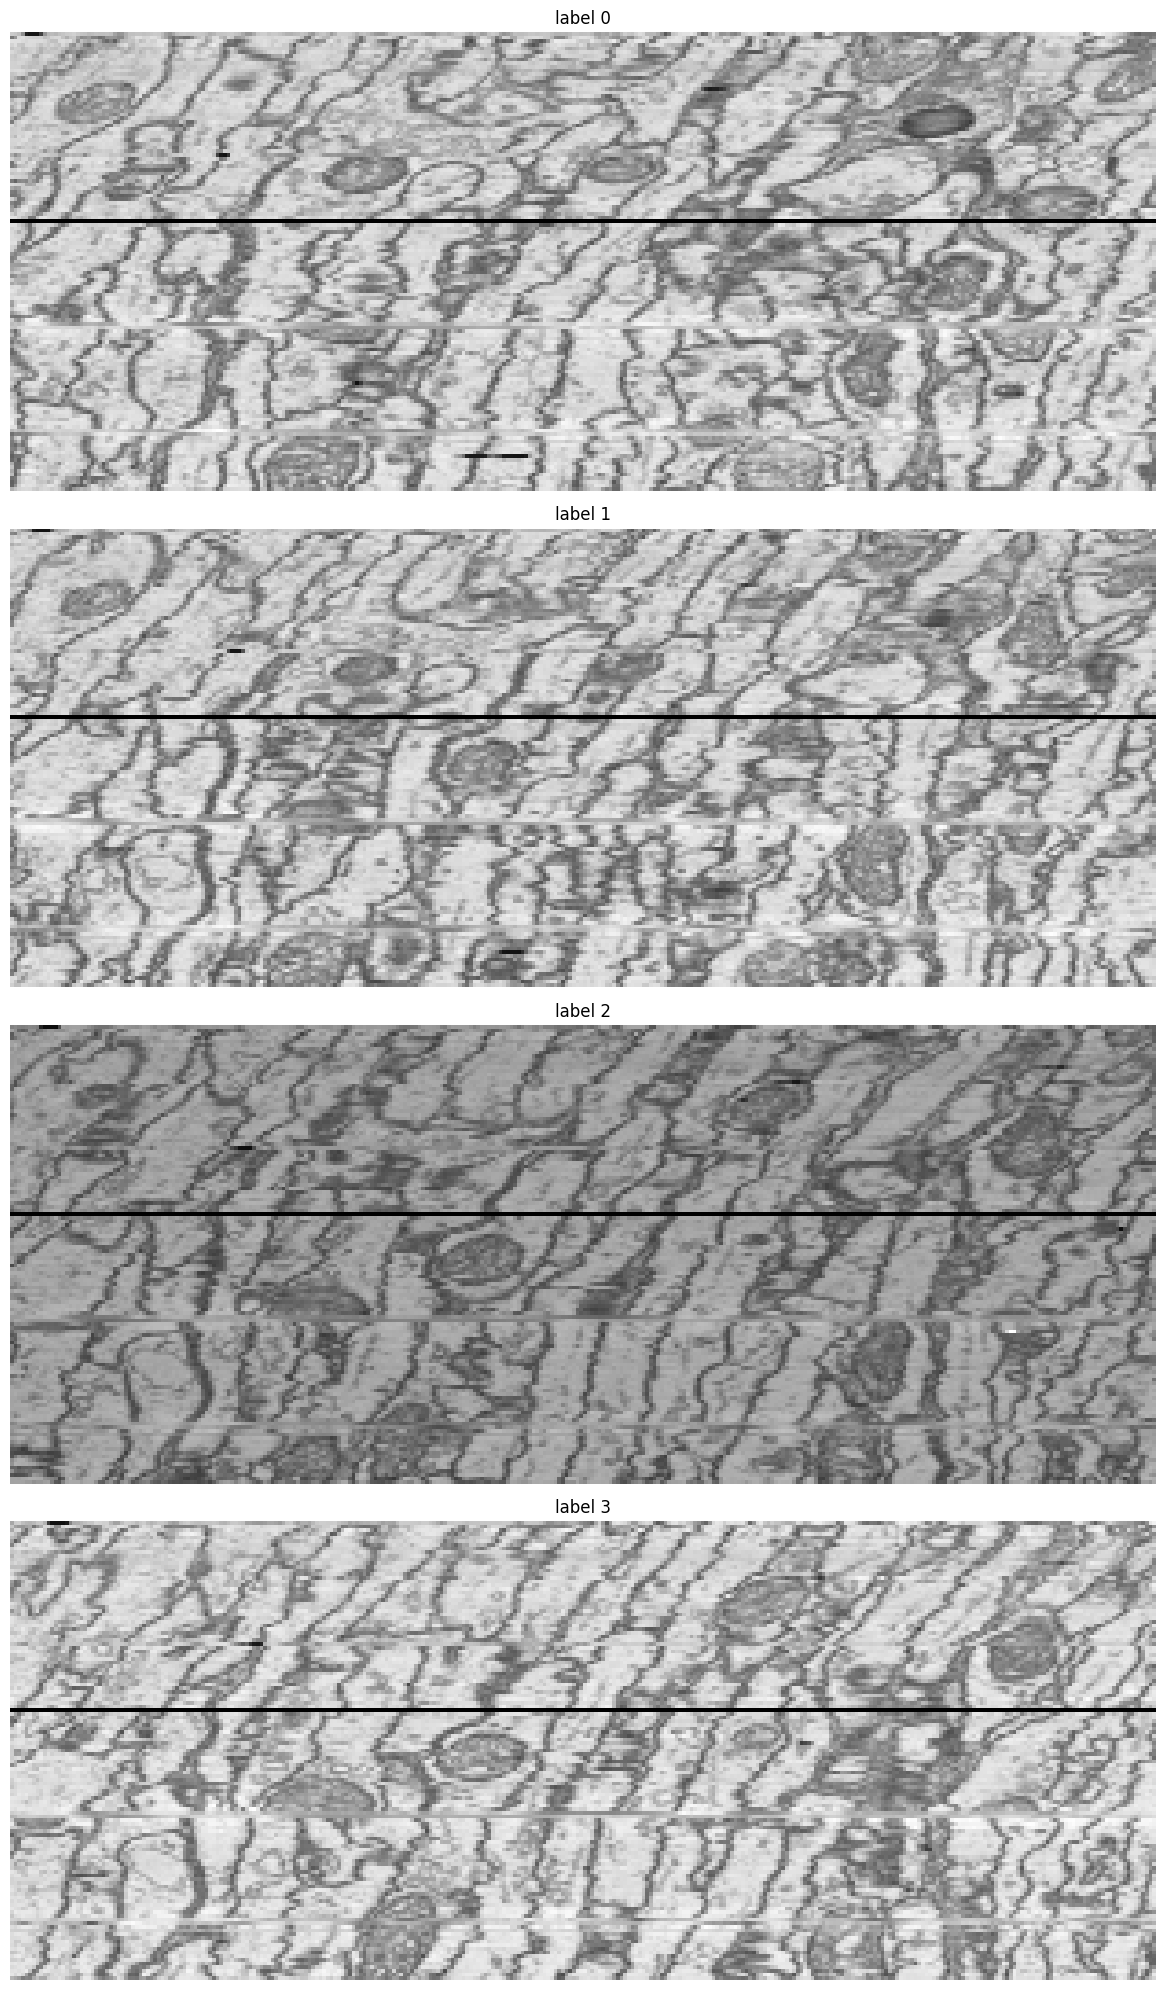

In [ ]:
images = [data[:,:500,it*5] for it in range(4)]
plot_images(images, size = (4,1), figsize=(20,20), resize_to_square=False)

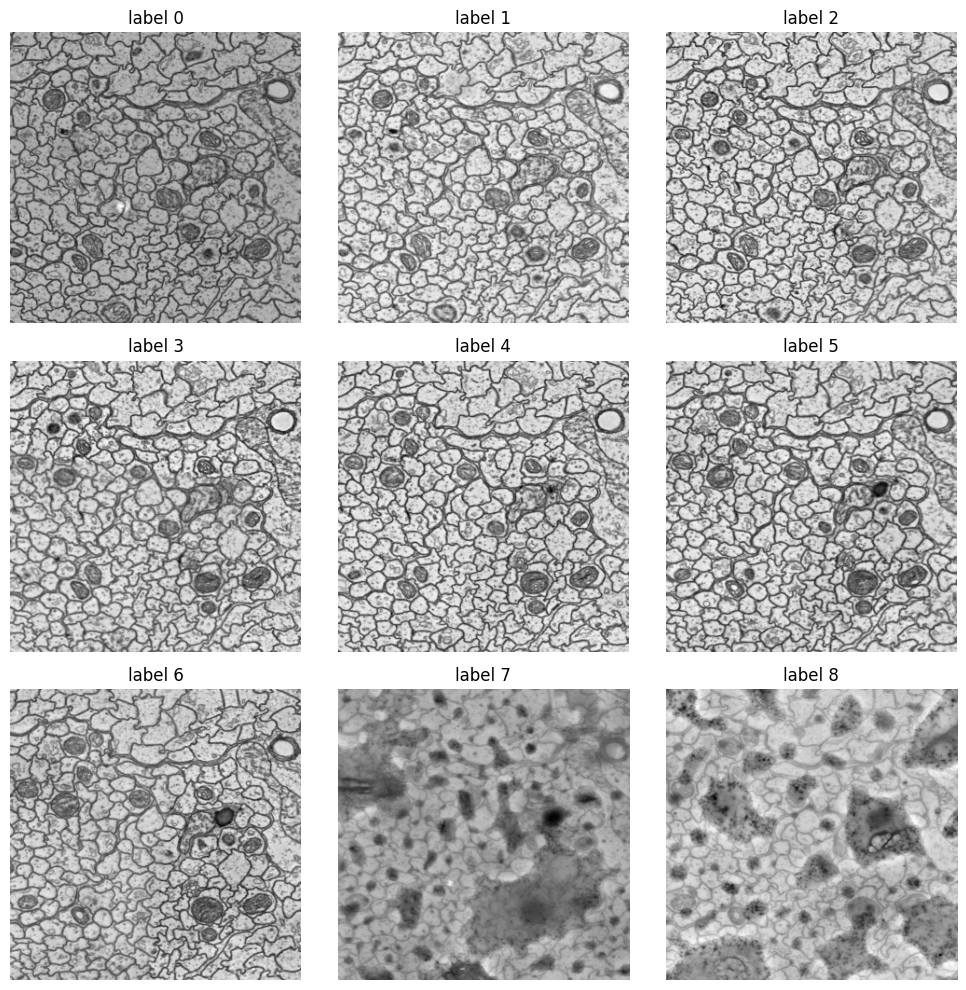

In [ ]:
# images = data[50:59]
images = data[101:110]
plot_images(images, size = (3,3), resize_to_square=True)